In [2]:
%pip install scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#SoftMax Functions

def softmax(z):
    """
    z : (n_samples, n_classes)
    Returns probabilities (n_samples, n_classes) – each row sums to 1
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Cost function
def cost_softmax(X, y_onehot, W, b):
    """
    X       : (n, d)
    y_onehot: (n, c) one-hot
    W       : (d, c)
    b       : (c,)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    # - (1/n) * sum (y * log ŷ)
    return -np.sum(y_onehot * np.log(y_pred + 1e-12)) / n

Note: you may need to restart the kernel to use updated packages.


In [3]:
#gradient computation 

def compute_gradient_softmax(X, y_onehot, W, b):
    """
    Returns grad_W (d,c), grad_b (c,)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    
    error = y_pred - y_onehot          # (n, c)
    grad_W = np.dot(X.T, error) / n    # (d, c)
    grad_b = np.sum(error, axis=0) / n # (c,)
    
    return grad_W, grad_b

In [4]:
#gradient desecent

def gradient_descent_softmax(X, y_onehot, W, b, alpha, n_iter, print_every=100):
    """
    Returns: final W, final b, cost_history list
    """
    cost_history = []
    
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y_onehot, W, b)
        
        W = W - alpha * grad_W
        b = b - alpha * grad_b
        
        current_cost = cost_softmax(X, y_onehot, W, b)
        cost_history.append(current_cost)
        
        if i % print_every == 0 or i == n_iter-1:
            print(f"Iter {i:4d}   cost = {current_cost:.6f}")
    
    return W, b, cost_history

In [5]:
#prediction functions


def predict_proba(X, W, b):
    z = np.dot(X, W) + b
    return softmax(z)


def predict_class(X, W, b):
    probs = predict_proba(X, W, b)
    return np.argmax(probs, axis=1)

Train shape: (120, 4),  Test shape: (30, 4)
Classes in train: [40 40 40]

Starting training ...

Iter    0   cost = 0.850067
Iter  200   cost = 0.150633
Iter  400   cost = 0.107092
Iter  600   cost = 0.089289
Iter  800   cost = 0.079444
Iter 1000   cost = 0.073114
Iter 1200   cost = 0.068659
Iter 1400   cost = 0.065328
Iter 1499   cost = 0.063968


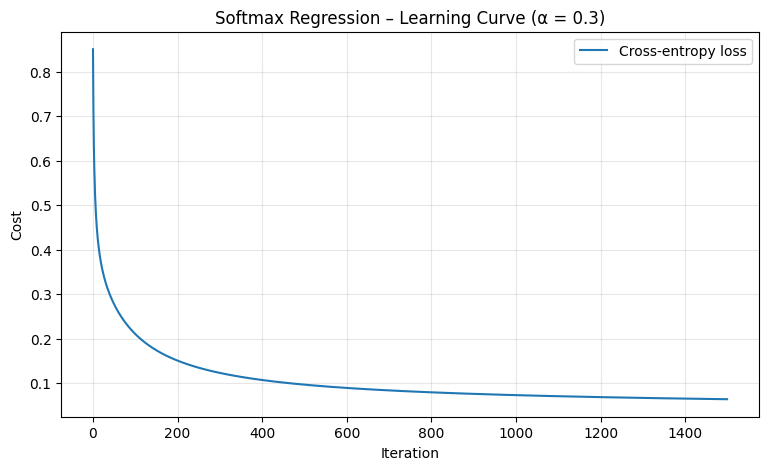


Final Results:
  Train accuracy : 97.50%
  Test  accuracy : 96.67%
  Final train cost: 0.063968

Confusion Matrix (test set):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [6]:
#main workflow

def main():
    # Load Iris
    iris = load_iris()
    X_raw = iris.data          
    y_raw  = iris.target       
    
    # One-hot encode targets
    encoder = OneHotEncoder(sparse_output=False)
    y_onehot = encoder.fit_transform(y_raw.reshape(-1, 1))   
    
    # Train / test split
    X_train_raw, X_test_raw, y_train_onehot, y_test_onehot = train_test_split(
        X_raw, y_onehot,
        test_size=0.2,
        random_state=42,
        stratify=y_raw
    )
    
    # Standard scaling 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)
    
    print(f"Train shape: {X_train.shape},  Test shape: {X_test.shape}")
    print(f"Classes in train: {np.bincount(np.argmax(y_train_onehot, axis=1))}")
    

    n_features = X_train.shape[1]   # 4
    n_classes  = y_train_onehot.shape[1]   # 3
    
    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)
    
    alpha   = 0.3      
    n_iter  = 1500
    
    print("\nStarting training ...\n")
    
    W_opt, b_opt, cost_history = gradient_descent_softmax(
        X_train, y_train_onehot, W, b,
        alpha=alpha, n_iter=n_iter, print_every=200
    )
    
    # ─── Plot learning curve ───
    plt.figure(figsize=(9,5))
    plt.plot(cost_history, label='Cross-entropy loss')
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'Softmax Regression – Learning Curve (α = {alpha})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # ─── Evaluation ───
    y_train_pred = predict_class(X_train, W_opt, b_opt)
    y_test_pred  = predict_class(X_test,  W_opt, b_opt)
    
    y_train_true = np.argmax(y_train_onehot, axis=1)
    y_test_true  = np.argmax(y_test_onehot, axis=1)
    
    train_acc = np.mean(y_train_pred == y_train_true) * 100
    test_acc  = np.mean(y_test_pred  == y_test_true)  * 100
    
    print("\nFinal Results:")
    print(f"  Train accuracy : {train_acc:5.2f}%")
    print(f"  Test  accuracy : {test_acc:5.2f}%")
    print(f"  Final train cost: {cost_history[-1]:.6f}")
    
    # Simple confusion matrix (test set)
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test_true, y_test_pred)
    print("\nConfusion Matrix (test set):")
    print(cm)


if __name__ == "__main__":
    main()